In [3]:
# =========================================================
# LIMPIEZA DE DATOS: TGEU TRANS MURDER MONITORING — COLOMBIA
# Filtra el CSV global de TGEU a Colombia, limpia texto libre
# inconsistente (ciudad, "desconocido" en variantes), ordena
# variables categóricas, y exporta un CSV listo para análisis.
# =========================================================

# --- CELDA 1: Cargar el CSV global descargado de TGEU ---
import pandas as pd
import numpy as np

df = pd.read_csv('/content/TGEU.csv')
print(f"Registros totales (todos los países): {df.shape[0]}")
print(f"Países/territorios distintos: {df['Country/territory of the murder'].nunique()}")

Registros totales (todos los países): 5320
Países/territorios distintos: 91


In [26]:
# --- CELDA 2: Filtrar a Colombia con coincidencia exacta ---
# Se usa == en vez de .str.contains() porque el campo de país viene
# codificado como "Región, Subregión::País" y un contains podría
# arrastrar por error otro país cuyo nombre esté contenido en el de
# otra región (ej. "Guinea" dentro de "Guinea-Bisáu").
PAIS_COLOMBIA = 'Sudamérica, Latinoamérica y el Caribe::Colombia'

col = df[df['Country/territory of the murder'] == PAIS_COLOMBIA].copy()
print(f"\nRegistros de Colombia: {len(col)}")

# Verificación de completitud antes de limpiar
print("\n% de valores nulos por columna:")
print((col.isna().mean() * 100).round(1).sort_values(ascending=False).head(10))


Registros de Colombia: 306

% de valores nulos por columna:
Documentos                         100.0
Archivos adjuntos                  100.0
Reported by                          2.0
Country/territory of the murder      0.0
Título                               0.0
Fecha de creación                    0.0
Plantilla                            0.0
Sex Characteristics                  0.0
Sexual Orientation                   0.0
Occupation                           0.0
dtype: float64


In [27]:
# --- CELDA 3: Descartar columnas sin uso analítico ---
# 'Documentos' y 'Archivos adjuntos' están 100% vacías para Colombia;
# 'Título', 'Fecha de creación' y 'Plantilla' son metadatos internos
# de la plataforma TGEU, no del caso en sí.
columnas_descartar = ['Documentos', 'Archivos adjuntos', 'Título',
                       'Fecha de creación', 'Plantilla', 'Publicado']
col = col.drop(columns=[c for c in columnas_descartar if c in col.columns])

In [28]:
# --- CELDA 4: Unificar las variantes de "desconocido" ---
# El dataset mezcla "desconocido", "desconocido / no aplicable",
# "unknown", "sin datos", "unknown / not applicable", etc. Se
# unifican todas a un solo valor NaN real, para que el conteo de
# "cuánto no sabemos" sea consistente entre columnas.
VARIANTES_DESCONOCIDO = [
    'desconocido', 'desconocido / no aplicable', 'unknown',
    'unknown / not applicable', 'sin datos', 'no aplicable', 'n/a', ''
]

def unificar_desconocidos(serie):
    return serie.apply(
        lambda x: np.nan if isinstance(x, str) and x.strip().lower() in VARIANTES_DESCONOCIDO else x
    )

columnas_texto = col.select_dtypes(include='object').columns
for c in columnas_texto:
    col[c] = unificar_desconocidos(col[c])

print("Valores únicos restantes en 'Response from local authorities':")
print(col['Response from local authorities'].value_counts(dropna=False))

Valores únicos restantes en 'Response from local authorities':
Response from local authorities
NaN                              214
caso en investigación             70
autor detenido                    10
sospechoso identificado            4
caso desestimado                   2
autor acusado                      2
sospechoso declarado inocente      1
otro                               1
autor sentenciado                  1
sospechoso detenido                1
Name: count, dtype: int64


In [29]:
# --- CELDA 5: Normalizar ciudad y extraer departamento (versión robusta) ---
# La ciudad viene como texto libre con varios problemas distintos:
#   a) La misma ciudad escrita de formas distintas ("Santiago de Cali" / "Cali")
#      o sin tilde ("Bogota" / "Bogotá", "Monteria" / "Montería").
#   b) Departamentos completos reportados como si fueran ciudad (ej. alguien
#      solo sabía que fue en "Valle del Cauca", sin precisar el municipio).
#   c) Errores geográficos reales en la fuente (ej. "Cúcuta, Santander":
#      Cúcuta es capital de Norte de Santander, no de Santander).
# Cada corrección queda documentada explícitamente abajo, no aplicada en
# silencio.
import unicodedata

def sin_tildes(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

DEPARTAMENTOS = [
    'Amazonas', 'Antioquia', 'Arauca', 'Atlántico', 'Bolívar', 'Boyacá', 'Caldas',
    'Caquetá', 'Casanare', 'Cauca', 'Cesar', 'Chocó', 'Córdoba', 'Cundinamarca',
    'Guainía', 'Guaviare', 'Huila', 'La Guajira', 'Magdalena', 'Meta', 'Nariño',
    'Norte de Santander', 'Putumayo', 'Quindío', 'Risaralda',
    'San Andrés y Providencia', 'Santander', 'Sucre', 'Tolima', 'Valle del Cauca',
    'Vaupés', 'Vichada', 'Bogotá D.C.'
]
DEP_NORM = {sin_tildes(d).lower(): d for d in DEPARTAMENTOS}

# Variantes de escritura de la misma ciudad (con/sin tilde, nombre largo/corto)
ALIAS_CIUDAD = {
    'santiago de cali': 'Cali', 'bogota': 'Bogotá', 'ibague': 'Ibagué',
    'monteria': 'Montería', 'popayan': 'Popayán', 'garzon': 'Garzón',
    'chinchina': 'Chinchiná', 'ciudad armenia': 'Armenia',
}
# Errores de tipeo en el nombre del departamento
ALIAS_DEPTO_TYPO = {
    'risalda': 'Risaralda', 'valle de cauca': 'Valle del Cauca',
    'valle det cauca': 'Valle del Cauca',
}
# Corrección de un error geográfico real detectado en la fuente (no de
# nuestra limpieza): Cúcuta pertenece a Norte de Santander, no a Santander.
CORRECCION_DEPTO_CONOCIDA = {'cucuta': 'Norte de Santander'}

# Casos resueltos manualmente contra fuentes externas (verificado el
# departamento, aunque el municipio exacto sigue sin poder confirmarse
# con el dato disponible): San Antonio y Chaparral son dos municipios
# vecinos, ambos en el departamento del Tolima.
DEPTO_RESUELTO_MANUAL = {'san antonio-chaparral': 'Tolima'}

# Casos donde, tras revisión manual, NO fue posible resolver la ubicación
# con confianza razonable (topónimos ambiguos entre varios lugares
# posibles en Colombia, o sin ningún dato de ubicación en absoluto).
# Se dejan explícitamente como desconocidos en vez de adivinar.
UBICACION_NO_RESUELTA = ['sucre', 'santa fe', 'santa fé', 'barrio la mina']

def limpiar_ciudad(valor):
    """Devuelve (ciudad_limpia, departamento, solo_departamento_reportado)."""
    if pd.isna(valor) or str(valor).strip().lower() == 'unknown':
        return np.nan, np.nan, False

    partes = [p.strip() for p in str(valor).split(',')]
    ciudad_raw = partes[0].strip()
    ciudad_key = sin_tildes(ciudad_raw).lower()

    # Caso: el campo entero es en realidad el nombre de un departamento,
    # sin municipio (ej. "Valle del Cauca" a secas)
    if len(partes) == 1:
        dep_directo = DEP_NORM.get(ciudad_key) or ALIAS_DEPTO_TYPO.get(ciudad_key)
        if dep_directo:
            return np.nan, dep_directo, True
        if ciudad_key == 'colombia':
            return np.nan, np.nan, False

    ciudad_limpia = ALIAS_CIUDAD.get(ciudad_key, ciudad_raw)

    if ciudad_key in DEPTO_RESUELTO_MANUAL:
        return ciudad_limpia, DEPTO_RESUELTO_MANUAL[ciudad_key], False
    if ciudad_key in UBICACION_NO_RESUELTA:
        return 'Sin resolver (ver revisión manual)', np.nan, False

    departamento = np.nan
    if len(partes) > 1:
        dep_key = sin_tildes(partes[1].strip()).lower()
        departamento = ALIAS_DEPTO_TYPO.get(dep_key) or DEP_NORM.get(dep_key) or partes[1].strip().title()
        if ciudad_key in CORRECCION_DEPTO_CONOCIDA:
            departamento = CORRECCION_DEPTO_CONOCIDA[ciudad_key]

    return ciudad_limpia, departamento, False

col[['ciudad_limpia', 'departamento', 'solo_departamento_reportado']] = col['City of the murder'].apply(
    lambda v: pd.Series(limpiar_ciudad(v))
)

print("Casos donde la fuente solo reportó el departamento, sin municipio:")
print(col[col['solo_departamento_reportado']]['departamento'].value_counts())
print(f"\nTotal: {col['solo_departamento_reportado'].sum()} de {len(col)} casos "
      f"({col['solo_departamento_reportado'].mean()*100:.1f}%) sin municipio identificado")

print("\nTop 15 ciudades después de la limpieza:")
print(col['ciudad_limpia'].value_counts().head(15))

Casos donde la fuente solo reportó el departamento, sin municipio:
departamento
Valle del Cauca    11
Huila               3
Sucre               3
Quindío             2
Risaralda           2
Tolima              2
Atlántico           1
La Guajira          1
Bolívar             1
Magdalena           1
Name: count, dtype: int64

Total: 27 de 306 casos (8.8%) sin municipio identificado

Top 15 ciudades después de la limpieza:
ciudad_limpia
Cali            42
Bogotá          34
Medellín        27
Barranquilla    17
Armenia          6
Bucaramanga      6
Pereira          5
Sincelejo        5
Caucasia         5
Santa Marta      5
Manizales        4
Riohacha         4
Cartagena        4
Maicao           3
Palmira          3
Name: count, dtype: int64


In [30]:
# --- CELDA 6: Convertir el rango de edad a categoría ordenada ---
orden_edad = ['15 a 18', '19 a 25', '26 a 30', '31 a 40', '41 a 50', '51 a 60', '61 a 70']
col['Age range'] = pd.Categorical(col['Age range'], categories=orden_edad, ordered=True)

print("\nDistribución de rango de edad (excluyendo desconocidos):")
print(col['Age range'].value_counts().sort_index())
print(f"\n'Desconocido' en rango de edad: {col['Age range'].isna().sum()} de {len(col)} casos "
      f"({col['Age range'].isna().mean()*100:.1f}%)")


Distribución de rango de edad (excluyendo desconocidos):
Age range
15 a 18     8
19 a 25    50
26 a 30    52
31 a 40    43
41 a 50    20
51 a 60     5
61 a 70     3
Name: count, dtype: int64

'Desconocido' en rango de edad: 125 de 306 casos (40.8%)


In [18]:
# --- CELDA 7: Asegurar que el año esté como entero ---
col['Calendar year'] = pd.to_numeric(col['Calendar year'], errors='coerce').astype('Int64')

In [31]:
# --- CELDA 8: Variable derivada — ¿hubo alguna respuesta institucional o no? ---
# Simplifica 'Response from local authorities' (con muchas categorías
# finas) a una bandera binaria útil para el eje de derechos humanos:
# ¿el Estado hizo algo identificable después del hecho, o no hay
# ningún rastro de acción?
SIN_RESPUESTA = ['sin datos']  # ya unificado a NaN en la celda 4, se deja explícito por transparencia

col['hubo_respuesta_institucional'] = col['Response from local authorities'].apply(
    lambda x: False if pd.isna(x) or x == 'caso desestimado' else True
)

print("\n¿Hubo alguna respuesta institucional identificable?")
print(col['hubo_respuesta_institucional'].value_counts())
print(f"Proporción sin ninguna respuesta identificable: "
      f"{(~col['hubo_respuesta_institucional']).mean()*100:.1f}%")


¿Hubo alguna respuesta institucional identificable?
hubo_respuesta_institucional
False    216
True      90
Name: count, dtype: int64
Proporción sin ninguna respuesta identificable: 70.6%


In [20]:
# --- CELDA 9: Revisión final antes de exportar ---
print(f"\nForma final del dataset limpio: {col.shape}")
print(col.dtypes)


Forma final del dataset limpio: (306, 29)
Country/territory of the murder             object
City of the murder                          object
Location of the murder                      object
Gender identity or expression               object
Sex Characteristics                         object
Sexual Orientation                          object
Occupation                                  object
Migrant status                              object
Nationality                                 object
Race                                        object
Age range                                 category
Disability                                  object
TDoR period (Oct-Sept)                      object
Calendar year                                Int64
Date of the incident                        object
Time of the incident                        object
Type of homicide/murder                     object
Type of location of the murder              object
Number of perpetrators                 

In [21]:
# --- CELDA 10: Exportar el CSV limpio ---
col.to_csv('/content/tgeu_colombia_limpio.csv', index=False)
print("\nExportado: tgeu_colombia_limpio.csv")


Exportado: tgeu_colombia_limpio.csv


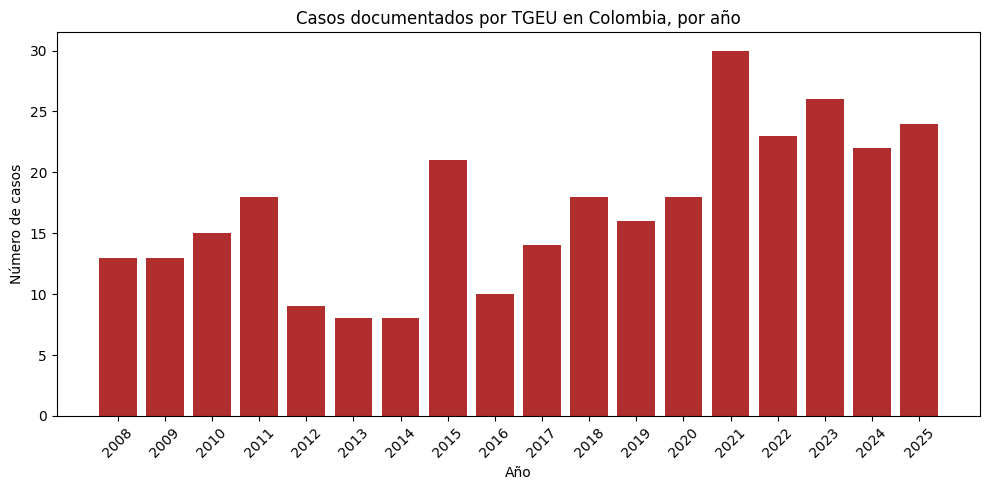

NOTA: un aumento en años recientes puede reflejar más violencia,
mejor documentación/monitoreo regional, o ambas — este gráfico por
sí solo no permite distinguir entre esas explicaciones.


In [32]:
# =========================================================
# EXPLORACIÓN INICIAL (para verificar que la limpieza sirvió,
# no como análisis final)
# =========================================================

# --- CELDA 11: Casos por año ---
import matplotlib.pyplot as plt

casos_por_año = col['Calendar year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(casos_por_año.index.astype(str), casos_por_año.values, color='#B02E2E')
plt.title('Casos documentados por TGEU en Colombia, por año')
plt.xlabel('Año')
plt.ylabel('Número de casos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("NOTA: un aumento en años recientes puede reflejar más violencia,")
print("mejor documentación/monitoreo regional, o ambas — este gráfico por")
print("sí solo no permite distinguir entre esas explicaciones.")

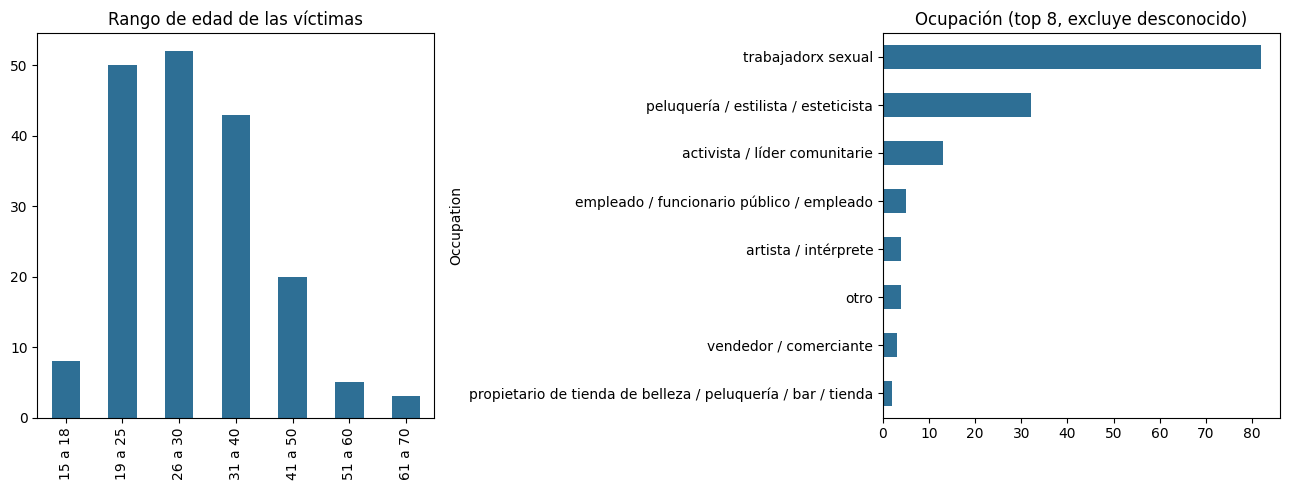

In [33]:
# --- CELDA 12: Perfil demográfico básico ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

col['Age range'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#2E6F95')
axes[0].set_title('Rango de edad de las víctimas')
axes[0].set_xlabel('')

col['Occupation'].value_counts().head(8).plot(kind='barh', ax=axes[1], color='#2E6F95')
axes[1].set_title('Ocupación (top 8, excluye desconocido)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

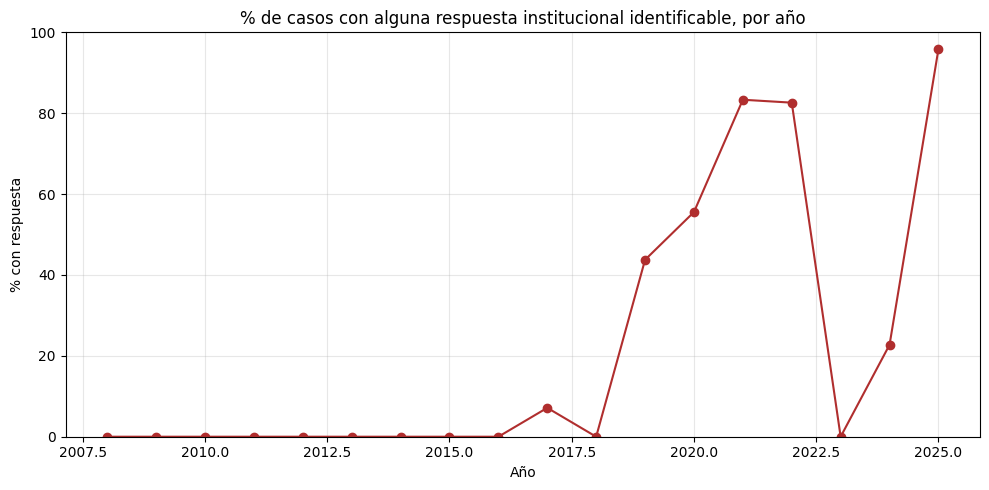

In [34]:
# --- CELDA 13: Respuesta institucional a lo largo del tiempo ---
respuesta_por_año = col.groupby('Calendar year')['hubo_respuesta_institucional'].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(respuesta_por_año.index, respuesta_por_año.values, marker='o', color='#B02E2E')
plt.title('% de casos con alguna respuesta institucional identificable, por año')
plt.xlabel('Año')
plt.ylabel('% con respuesta')
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()